# Automated Track Infrastructure Recognition by Using Vibration Analysis
Kooros Moabber Lule˚a University, Lule˚a, Sweden and Volvo Cars Corporation, Gothenburg, Sweden


## Introduction
Track infrastructure monitoring is critical for optimizing KPIs such as efficiency, cost, availability and safety. This monitoring is more crucial when the infrastructure is in a harsh environment and wore out due to age. Traditional maintenance is based on periodic inspections which is time consuming and costly and should be replaced with a predictive maintenance where an AI-driven approach for automated real time track monitoring is one of the best approaches. This monitoring can be done on all elements of infrastructure particularly turnouts, joins and bridges that are more vulnerable for any problem.

An approach for this monitoring is to measure the vibration detected caused by train on track by accelerometer in a specific infrastructure and combine this vibration data with GPS and expected/predefined infrastructure information to detect infrastructure elements (events) and compare their acceleration pattern with a normal pattern to detect any abnormally.

In this report, The labeling of infrastructure elements is our target. for this purpose, the infrastructure elements which is located in specific GPS points and data files are gathered from reality are used to label every vibration segment with the corresponding categorical label (Bridge, Rail-joint, Turnout, and other). Since the size of data is really high and there are many unnecessary data, only the points actually travelled (Bridge, Rail-joint, Turnout) are kept.

![System Setup](TrainSetup.png)
**Figure 1:** Measurement System Implementation


## Method
The methodology begins with the installation of measurement equipment, including accelerometers and GPS sensors, on a train to collect vibration and positioning data during operation.

In the first step, marker data, GPS data, and the corresponding vibration data (stored in Part 2) are loaded and prepared for analysis.

In the second step, invalid data points are removed based on predefined criteria. Specifically, data collected at low speeds (below a threshold) and with insufficient GPS satellite coverage (below a threshold) are filtered out. This ensures that only reliable data recorded during actual train movement is retained.

In the third step, the GPS and vibration data are spatially filtered to retain only segments corresponding to actual traversal over infrastructure elements such as bridges, rail joints, and turnouts. Two approaches are considered:

- GPS-to-element matching: For each GPS point, the nearest infrastructure elements are identified within a specified maximum range (dynamic distance threshold). Those GPS points that have events are marked as elements.
- Event-to-element matching: For each GPS point when its corresponding segment has event, the nearest infrastructure marker/element within a specified maximum range is identified and marked.

Finally, each vibration segment is assigned a categorical label (Bridge, Rail-joint, Turnout, or Other) based on the selected approach, and the processed dataset is saved for further analysis.


## Results and Analysis
Let's start by importing the necessary packages (mostly from assignment 3):

In [1]:
import os
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import warnings
import kaleido
from IPython.display import HTML, display, Markdown
import matplotlib
import matplotlib.pyplot as plt
import plotly.express as px
from plotly.subplots import make_subplots
from pathlib import Path
import scipy.stats as stats
from scipy.stats import norm
from scipy.stats import kurtosis
from scipy.stats import skew
from scipy.stats import shapiro
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import cross_validate
from sklearn.neighbors import BallTree
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestClassifier

In [2]:
def crest_factor(x):
    x = np.asarray(x)
    rms = np.sqrt(np.mean(x**2))
    peak = np.max(np.abs(x))
    return peak / (rms + 1e-12)

def get_vibration_segment(gps_time, vib_df, delta_t=0.2):
#Returns vibration samples around a GPS timestamp for the correct GPS to vibration linkage.
    return vib_df[
        (vib_df["timestamp"] >= gps_time - delta_t) &
        (vib_df["timestamp"] <= gps_time + delta_t)
    ]

### Data Extraction and Manipulation
First element/marker data is read to show on map later. There are some duplicate point in this data that should be removed.

In [3]:
marker_styles = {
    "Bridge": {"color": "red", "size": 10},
    "RailJoint": {"color": "blue", "size": 8},
    "Turnout": {"color": "green", "size": 12}
}

color_map = {
    "Bridge": "red",
    "Rail-joint": "blue",
    "Turnout": "green"
}

symbol_map = {
    "Bridge": "circle",
    "Rail-joint": "square",
    "Turnout": "triangle"
}

file_name_data="Data1/gps_marker_data.csv"
marker_raw= pd.read_csv(file_name_data, encoding="utf-8")
print(f"Marker data loaded")
duplicates = marker_raw.duplicated(subset=["Latitude", "Longitude","Category"], keep=False)
print("Duplicate marker:")
print(marker_raw[duplicates])
marker_data = marker_raw.drop_duplicates(subset=["Latitude", "Longitude","Category"]).copy()

marker_data.shape
# marker_data.info()
# print(marker_data.head(120))

Marker data loaded
Duplicate marker:
     Latitude  Longitude Category
55  60.689513  15.107465  Turnout
56  60.689513  15.107465  Turnout


(119, 3)

In this step we are loading the GPS and vibration file that has been selected in previous part and categorized as good data. To make data categorized, a field file_label is added to GPS and vibration data frames to show that specific GPS data belongs to which file. Besides, a field (gps_index) is added to vibration data to connect vibration data to its relevant GPS point. 

In [4]:
gps_dataframes = {}
vib_dataframes = {}
folders={
    "file1": "Data2/2024-12-10 10-00-00 (1)/",
    "file2": "Data2/2024-12-10 12-00-00 (1)/"
    #"file3": "Data2/2024-12-10 16-00-00 (1)/"
    #"file4": "Data2/2024-12-11 06-00-00 (1)/"
    #"file5": "Data2/2024-12-11 10-00-00 (1)/"
    #"file6": "Data2/2024-12-11 16-00-00 (1)/"
    #"file7": "Data2/2024-12-11 18-00-00 (1)/"
    #"file8": "Data2/2024-12-12 10-00-00 (1)/"
    #"file9": "Data2/2024-12-12 12-00-00 (1)/"
}
for file_label, folder_path in folders.items():
    df_gps = pd.read_csv(f"{folder_path}gps_data.csv", encoding="utf-8") 
    df_speed=pd.read_csv(f"{folder_path}speed_data.csv", encoding="utf-8")
    df_gps=pd.merge(df_gps,df_speed,on="timestamp")
    df_gps_no=pd.read_csv(f"{folder_path}gps_no_data.csv", encoding="utf-8")
    df_gps=pd.merge(df_gps,df_gps_no,on="timestamp")
    df_gps["file_label"]=file_label
    gps_dataframes[file_label] = df_gps
    #gps_dataframes[file_label].info()
    #print(gps_dataframes[file_label].head(5))
    df_vib=pd.read_csv(f"{folder_path}vibration_data.csv", encoding="utf-8")
    df_vib["file_label"]=file_label
    vib_dataframes[file_label] = df_vib
    index_factor=len(df_vib)//len(df_gps)
    df_vib["gps_index"]=df_vib.index//index_factor


    
    #vib_dataframes[file_label].info()
    #print(vib_dataframes[file_label].head(5))
gps_combined = pd.concat(gps_dataframes.values(), axis=0, ignore_index=True)
vib_combined = pd.concat(vib_dataframes.values(), axis=0, ignore_index=True)

print(f"Combined gps size: {gps_combined.shape} and vibration size: {vib_combined.shape}")
#gps_combined.info()
print(gps_combined.head(5))
#print(gps_combined["PointIndex"].max())
print(gps_combined.isna().sum())

#vib_combined.info()
print(vib_combined.head(5))
#print(vib_combined["timestamp"].max())
print(vib_combined.isna().sum())


Combined gps size: (72000, 9) and vibration size: (72000001, 5)
    Latitude  timestamp  Longitude  PointIndex      speed  speed_mps  \
0  60.904847          0  14.837729           0  142.46850  39.574585   
1  60.904902          1  14.837636           1  142.28351  39.523197   
2  60.904956          2  14.837545           2  142.35750  39.543750   
3  60.905009          3  14.837455           3  142.45000  39.569443   
4  60.905062          4  14.837366           4  142.52400  39.590000   

   distance  GPS_no file_label  
0  1.978729       4      file1  
1  3.954889       4      file1  
2  5.932077       4      file1  
3  7.910549       4      file1  
4  9.890049       4      file1  
Latitude      0
timestamp     0
Longitude     0
PointIndex    0
speed         0
speed_mps     0
distance      0
GPS_no        0
file_label    0
dtype: int64
   Vibration1  timestamp  Vibration2 file_label  gps_index
0    0.938714          0    1.139024      file1          0
1   -4.282488          1    0.

Three filters have been implemented:
- speed
- GPS satellite no
- Spatial filtering
    - GPS point to the nearest element
    - Element to the nearest marker/element point

In this step any invalid or less valid GPS data are removed. There are some points where they are not on track and even in the middle of sea that investigations show that the number of GPS satellite number is 2 or less therefore at least four satellite data makes data more valid. Besides, there are many data that train are not moving to pass through elements therefore those GPS data and those relevant vibrations data are removed. When the train is stopped, some vibrations data have been observed that should be due to other train passing.

In [5]:
# Help from Claude
speed_threshold=10
gps_no_threshold=2

valid = (
    (gps_combined["speed"] >= speed_threshold) &
    (gps_combined["GPS_no"] >= gps_no_threshold)
)

gps_filtered = gps_combined[valid].copy()

vib_filtered = vib_combined.merge(
    gps_filtered[["file_label", "PointIndex"]],
    left_on=["file_label", "gps_index"],
    right_on=["file_label", "PointIndex"],
    how="inner"
)

print(gps_filtered.shape)
print(vib_filtered.shape)
#print(gps_filtered.head(5))
#print(vib_filtered.head(5))
#print(gps_filtered.isna().sum())
#print(vib_filtered.isna().sum())

(32761, 9)
(32744598, 6)


In this step all loaded GPS data after filtering and elements (markers) are visualized to visualize there is no abnormality and confirm that there are GPS data close to all elements.

In [6]:
import warnings
import plotly.graph_objects as go

warnings.filterwarnings("ignore")

fig = go.Figure()

# Plot markers (Bridge, Turnout, joint rail) ---
for category, style in marker_styles.items():
    category_data = marker_data[marker_data["Category"] == category]
    
    if len(category_data) > 0:
        fig.add_trace(go.Scattermapbox(
            lat=category_data["Latitude"],
            lon=category_data["Longitude"],
            mode="markers",
            marker=dict(
                color=style["color"],
                size=style["size"]
            ),
            name=f"Marker: {category}"
        ))
    else:
        print(f"Skipping {category} - no marker data")

# Plot selected GPS points ---
gps_plot = gps_filtered.copy()   # already filtered (no "Other")

fig.add_trace(go.Scattermapbox(
    lat=gps_plot["Latitude"],
    lon=gps_plot["Longitude"],
    mode="markers",
    marker=dict(
        color="black",
        size=4,
        opacity=0.5
    ),
    name="Selected GPS"
))

# Layout
fig.update_layout(
    mapbox_style="open-street-map",
    title="Railway Map with Markers and GPS Points After Filtering",
    legend_title_text="Legend",
    width=1200,
    height=800,
    margin={"r": 0, "t": 50, "l": 50, "b": 0},
    mapbox=dict(
        zoom=8.5,
        center=dict(
            lat=gps_plot["Latitude"].mean(),
            lon=gps_plot["Longitude"].mean()
        )
    )
)

if len(fig.data) == 0:
    print("WARNING: No valid traces were added to the figure!")

fig.show(renderer="iframe")

file_name_map="Combined_GPS_Marker.png"
fig.write_image(
        file_name_map ,
        width=1200,       # pixels
        height=800,       # pixels
        scale=2           # scale=2 doubles resolution (good for reports)
    )

Although only limited number of data files have been loaded due to the limited system resource, there are always close GPS neighborhoods to all elements except 8 turnout and 3 bridge.

The non-relevant GPS data and their vibrations data which are not relevant elements (close to elements) should be removed. There are two approaches:
- GPS point to the nearest element: select a GPS point and check what is the nearest element point in a maximum specific range (Dynamic distance threshold).
- Event to the nearest marker point: select a GPS point with event and find the nearest marker point if it is in a maximum specific range (distance threshold). 

### GPS Point to The Nearest Element Approach
In this approach , the GPS data has been used to find a element in a specific window.

First a backup of original data is used to save the original ones for later analysis and then GPS and marker location date (latitude and longitude) which are in degree are converted to radian angles.

In [7]:
# help from internet, chatgpt, claude and gemini

gps = gps_filtered.copy()
markers = marker_data.copy()
vib=vib_filtered.copy()

gps_coords = np.radians(gps[["Latitude", "Longitude"]].values)
marker_coords = np.radians(markers[["Latitude", "Longitude"]].values)

#missing = ~vib["gps_index"].isin(gps["PointIndex"])
#print(missing.sum())
print(f"GPS coordinates in radians: {gps_coords.shape}")
#print(gps_coords[0:4])
print(f"Marker/Element coordinates in radians: {marker_coords.shape}")
#print(marker_coords[0:4])



GPS coordinates in radians: (32761, 2)
Marker/Element coordinates in radians: (119, 2)


The BallTree method is used to find all elements close to a specific GPS point. BallTree is a binary tree where data points are organized into multi-dimensional "balls" (hyperspheres). A BallTree divides the points into groups. If a search "ball" doesn't intersect with a group's boundary, the algorithm skips that entire group instantly. This makes searching much faster, especially in higher dimensions. Standard distance (Euclidean) assumes the world is a flat map. The Haversine formula calculates the shortest distance between two points on the surface of a sphere. 

$$
d = 2r \arcsin\left(\sqrt{\sin^2\left(\frac{\phi_2 - \phi_1}{2}\right) + \cos(\phi_1) \cos(\phi_2) \sin^2\left(\frac{\lambda_2 - \lambda_1}{2}\right)}\right)
$$

In the query(X, k=...), the k parameter specifies how many nearest neighbors you want to find for each point in your query set X.

in this formula, The idx (index) array tells you "Who" the neighbors are. It contains the integer positions of the neighbors index. 

The dist array tells you "How far" those neighbors are and It contains the actual numerical distance between your query point and the neighbors found in idx.

In [8]:
gps_neighbors_no=1
marker_tree = BallTree(marker_coords, metric='haversine')
dist, idx = marker_tree.query(gps_coords, k=gps_neighbors_no)
#print(dist.size, idx.size)
#print([dist[0:5],idx[0:5]])


The above distance is on a earth sphere that should be converted to meter to be more applicable. The distance of the nearest neighbors and their indexes are calculated in this part. Minimum and recommended distance between GPS points and markers based on statistics are calculated.

In [9]:
earth_radius = 6371000
dist_m = dist.flatten() * earth_radius

dist1, idx1 = marker_tree.query(marker_coords, k=2)
nearest_dist = dist1[:, 1] * earth_radius
element_min_dist = nearest_dist.min()
recommended_threshold = np.percentile(nearest_dist, 10) / 2
# print(dist_m[0:4])
print(F"Minimum distance between two elements = {element_min_dist}")
print(F"Recommended distance threshold = {recommended_threshold}")


Minimum distance between two elements = 4.967369007114459
Recommended distance threshold = 5.830244379017097


In this part each GPS point where is close to an element (threshold_dist) is categorized as that element. Two methods are implemented:
- Static threshold: where the distance threshold is irrelevant to train speed. GPS sampling time is constant and in very low speed or high speed either over-sampled or miss part of event.
- Dynamic threshold: in this implementation, there are specific GPS point during a time window therefore there is too small window at low speed or too large window at high speed.

In [10]:
# help from internet, chatgpt, claude and gemini
#threshold_dist=10  # activate for static
time_window = 1  # time window
min_dist= 5 # minimum distance
gps["speed_mps"] = gps["speed"] / 3.6 # m/s
print(f"Maximum speed= {np.max(gps["speed_mps"])} m/s") 
gps["dynamic_threshold"] = np.maximum(min_dist, gps["speed_mps"] * time_window)

gps["Category"] = "Other"
nearest_categories = markers.iloc[idx.flatten()]["Category"].values
#mask = dist_m < threshold_dist   # activate for static
mask = dist_m < gps["dynamic_threshold"].values
gps.loc[mask, "Category"] = nearest_categories[mask]

print(f"No of detected elements= {len(nearest_categories[mask])} vs {len(marker_data)}")   
print(f"No of detected Bridge= {np.sum(gps["Category"]=="Bridge")} vs {np.sum(marker_data["Category"]=="Bridge")} real bridge")
print(f"No of detected Rail Joint= {np.sum(gps["Category"]=="RailJoint")} vs {np.sum(marker_data["Category"]=="RailJoint")} real rail joint")
print(f"No of detected Turnout= {np.sum(gps["Category"]=="Turnout")} vs {np.sum(marker_data["Category"]=="Turnout")} real rail Turnout")
print(f"No of detected Other= {np.sum(gps["Category"]=="Other")}")

Maximum speed= 44.132775 m/s
No of detected elements= 541 vs 119
No of detected Bridge= 143 vs 25 real bridge
No of detected Rail Joint= 207 vs 20 real rail joint
No of detected Turnout= 191 vs 74 real rail Turnout
No of detected Other= 32220


The number of selected segment is directly related threshold distance (static/dynamic). When this threshold is small, some of the elements cannot be detected and when it is big, many GPS point is connected to an element. 

It is observed that when the dynamic threshold is used, the resolution for elements that are close to together is much better.

There is possibility to extend the number of GPS points before and after to expand the selected segment although it increases the number of selected GPS points but it is helpful when the GPS point is far from element and the vibration segment is unclear. 

In [11]:
window = 1

valid_idx = np.where(mask)[0]

for i in valid_idx:
    start = max(0, i - window)
    end   = min(len(gps) - 1, i + window)
    gps.iloc[start:end+1, gps.columns.get_loc("Category")] = gps.iloc[i]["Category"]

print(f"No of detected elements= {sum(mask)*(end-start+1)} vs {len(marker_data)}")  
print(f"No of detected Bridge= {np.sum(gps["Category"]=="Bridge")} vs {np.sum(marker_data["Category"]=="Bridge")} real bridge")
print(f"No of detected Rail Joint= {np.sum(gps["Category"]=="RailJoint")} vs {np.sum(marker_data["Category"]=="RailJoint")} real rail joint")
print(f"No of detected Turnout= {np.sum(gps["Category"]=="Turnout")} vs {np.sum(marker_data["Category"]=="Turnout")} real rail Turnout")
print(f"No of detected Other= {np.sum(gps["Category"]=="Other")}")
    

No of detected elements= 1623 vs 119
No of detected Bridge= 183 vs 25 real bridge
No of detected Rail Joint= 249 vs 20 real rail joint
No of detected Turnout= 240 vs 74 real rail Turnout
No of detected Other= 32089


when the GPS points close to elements have been selected this shall be propagate to vibration data.

In [12]:
gps_labels = gps[["file_label", "PointIndex", "Category"]]

vib_labeled = vib.merge(
    gps_labels,
    left_on=["file_label", "gps_index"],
    right_on=["file_label", "PointIndex"],
    how="left"
)

print(f"All labeled GPS point numbers: {len(gps_labels)}")
print(f"All labeled vibrations point numbers: {len(vib_labeled)}")
#print(gps_labels.head(5))
#print(vib_labeled.head(5))

All labeled GPS point numbers: 32761
All labeled vibrations point numbers: 32744598


In this stage only elements relevant GPS and vibration data is kept therefore other shall be removed.

In [13]:
gps_labeled = gps[gps["Category"] != "Other"]
vib_labeled = vib_labeled[vib_labeled["Category"] != "Other"]

gps_labeled = gps_labeled[["Latitude", "timestamp", "Longitude", "PointIndex", "speed", "GPS_no", "file_label", "Category"]].copy()
vib_labeled = vib_labeled[["Vibration1", "timestamp", "Vibration2", "file_label", "gps_index", "Category"]].copy()

# print(gps_labeled.isna().sum())
# print(vib_labeled.isna().sum())
#print(gps_labeled.head(5))
#print(vib_labeled.head(5))
print(f"All selected labeled GPS point numbers: {len(gps_labeled)}")
print(f"All selected labeled vibrations point numbers: {len(vib_labeled)}")

All selected labeled GPS point numbers: 672
All selected labeled vibrations point numbers: 671497


The selected GPS points and elements are illustrated in this figure. Black markers are GPS points and other colors are elements.

In [14]:
warnings.filterwarnings("ignore")

fig1 = go.Figure()

# Plot markers (Bridge, Turnout, etc.) ---
for category, style in marker_styles.items():
    category_data = marker_data[marker_data["Category"] == category]
    
    if len(category_data) > 0:
        fig1.add_trace(go.Scattermapbox(
            lat=category_data["Latitude"],
            lon=category_data["Longitude"],
            mode="markers",
            marker=dict(
                color=style["color"],
                size=style["size"]
            ),
            name=f"Marker: {category}"
        ))
    else:
        print(f"Skipping {category} - no marker data")

# Plot selected GPS points ---
gps_plot = gps_labeled.copy()   # already filtered (no "Other")

fig1.add_trace(go.Scattermapbox(
    lat=gps_plot["Latitude"],
    lon=gps_plot["Longitude"],
    mode="markers",
    hovertext=gps_plot["Category"],
    marker=dict(
        color="black",
        size=4,
        opacity=0.5
    ),
    name="Selected GPS"
))

# Layout ---
fig1.update_layout(
    mapbox_style="open-street-map",
    title="Railway Map with Markers and Selected GPS Points (Approach 1)",
    legend_title_text="Legend",
    width=1200,
    height=800,
    margin={"r": 0, "t": 50, "l": 50, "b": 0},
    mapbox=dict(
        zoom=8.5,
        center=dict(
            lat=gps_plot["Latitude"].mean(),
            lon=gps_plot["Longitude"].mean()
        )
    )
)

if len(fig1.data) == 0:
    print("WARNING: No valid traces were added to the figure!")
else:
    figure_name="gps_elements_aproach1.png"
    fig1.write_image(
       figure_name,
        width=1200,       # pixels
        height=800,       # pixels
        scale=2           # scale=2 doubles resolution (good for reports)
    )
fig1.show(renderer="iframe")

The figure shows that many elements can be detected correctly in this approach. The problems in this approach are:
- some of elements are missed
- many GPS points dedicated to each element

If all element points have possibility to be selected, there is possible to select limited ones by filtering the vibration data but since all elements have not been detected even when the distance threshold or time window has been increased in the penalty of more GPS point dedicated to each element therefore this approach doesn't seem really realistic therefore the availability of events in each GPS point is removed here.

By using one-hot encoding, a binary data from dedicated category data has been generated before saving this approach data.


In [15]:
# Initialize binary columns
gps_labeled["Bridge"] = 0
gps_labeled["Turnout"] = 0
gps_labeled["RailJoint"] = 0

gps_labeled.loc[gps_labeled["Category"] == "Bridge", "Bridge"] = 1
gps_labeled.loc[gps_labeled["Category"] == "Turnout", "Turnout"] = 1
gps_labeled.loc[gps_labeled["Category"] == "RailJoint", "RailJoint"] = 1

file_name_df_gps_labeled=f"gps_labeled_data_approach1.csv"
gps_labeled.to_csv(file_name_df_gps_labeled, index=False)
file_name_df_vibration_labeled=f"vibration_labeled_data_approach1.csv"
vib_labeled.to_csv(file_name_df_vibration_labeled, index=False)

### Event to The Nearest element Point Approach
In this approach, for each selected GPS point that its vibrations data has event, the nearest element points and their neighbors if they are in a specific range (distance threshold) are found.

In the first step, a copy of original files after filtering is prepared and angles in GPS and marker/elements are converted to radians.

In [16]:
# help from internet, chatgpt, claude and gemini

gps = gps_filtered.copy()
markers = marker_data.copy()
vib=vib_filtered.copy()

gps_coords = np.radians(gps[["Latitude", "Longitude"]].values)
marker_coords = np.radians(markers[["Latitude", "Longitude"]].values)

Based on assignment 3, a kurtosis statistic is one of a good criteria to detect vibrations therefore the statistic feature is calculated for all GPS points to use it later for selection of event.

In [17]:
from scipy.stats import kurtosis
kurt_per_gps = vib.groupby(["file_label", "gps_index"])["Vibration1"].apply(
    lambda x: kurtosis(x, fisher=False)  # fisher=False → normal dist = 3
).reset_index()

kurt_per_gps.rename(columns={"Vibration1": "kurtosis"}, inplace=True)

gps = gps.merge(
    kurt_per_gps,
    left_on=["file_label", "PointIndex"],
    right_on=["file_label", "gps_index"],
    how="left"
)

Another feature that has been used is energy which is relevant to RMS value.

In [18]:
energy_per_gps = vib.groupby(["file_label", "gps_index"])["Vibration1"].apply(
    lambda x: np.mean(x**2)
).reset_index()

energy_per_gps.rename(columns={"Vibration1": "energy"}, inplace=True)

gps = gps.merge(
    energy_per_gps,
    left_on=["file_label", "PointIndex"],
    right_on=["file_label", "gps_index"],
    how="left"
)
gps.info()
gps.head(5)

<class 'pandas.DataFrame'>
RangeIndex: 32761 entries, 0 to 32760
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Latitude     32761 non-null  float64
 1   timestamp    32761 non-null  int64  
 2   Longitude    32761 non-null  float64
 3   PointIndex   32761 non-null  int64  
 4   speed        32761 non-null  float64
 5   speed_mps    32761 non-null  float64
 6   distance     32761 non-null  float64
 7   GPS_no       32761 non-null  int64  
 8   file_label   32761 non-null  str    
 9   gps_index_x  32761 non-null  int64  
 10  kurtosis     32761 non-null  float64
 11  gps_index_y  32761 non-null  int64  
 12  energy       32761 non-null  float64
dtypes: float64(7), int64(5), str(1)
memory usage: 3.2 MB


,Latitude,timestamp,Longitude,PointIndex,speed,speed_mps,distance,GPS_no,file_label,gps_index_x,kurtosis,gps_index_y,energy
0,60.904847,0,14.837729,0,142.46850,39.574585,1.978729,4,file1,0,2.671361,0,4.837055
1,60.904902,1,14.837636,1,142.28351,39.523197,3.954889,4,file1,1,2.753958,1,4.926262
2,60.904956,2,14.837545,2,142.35750,39.543750,5.932077,4,file1,2,2.556707,2,4.833287
3,60.905009,3,14.837455,3,142.45000,39.569443,7.910549,4,file1,3,2.862623,3,3.969896
4,60.905062,4,14.837366,4,142.52400,39.590000,9.890049,4,file1,4,2.825682,4,4.871165


After merging the Kurtosis and energy data in two steps, some extra columns have been generated that have been removed here. 

In [19]:
print(gps.columns)
if "gps_index_y" in gps.columns:
    gps=gps.drop(columns=["gps_index_y"])
    gps = gps.rename(columns={"gps_index_x": "gps_index"})

gps.info()
gps.head(5)
print(gps['gps_index'].max())
print(gps['PointIndex'].max())

Index(['Latitude', 'timestamp', 'Longitude', 'PointIndex', 'speed',
       'speed_mps', 'distance', 'GPS_no', 'file_label', 'gps_index_x',
       'kurtosis', 'gps_index_y', 'energy'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 32761 entries, 0 to 32760
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Latitude    32761 non-null  float64
 1   timestamp   32761 non-null  int64  
 2   Longitude   32761 non-null  float64
 3   PointIndex  32761 non-null  int64  
 4   speed       32761 non-null  float64
 5   speed_mps   32761 non-null  float64
 6   distance    32761 non-null  float64
 7   GPS_no      32761 non-null  int64  
 8   file_label  32761 non-null  str    
 9   gps_index   32761 non-null  int64  
 10  kurtosis    32761 non-null  float64
 11  energy      32761 non-null  float64
dtypes: float64(7), int64(4), str(1)
memory usage: 3.0 MB
35999
35999


In this step these features are visualized.

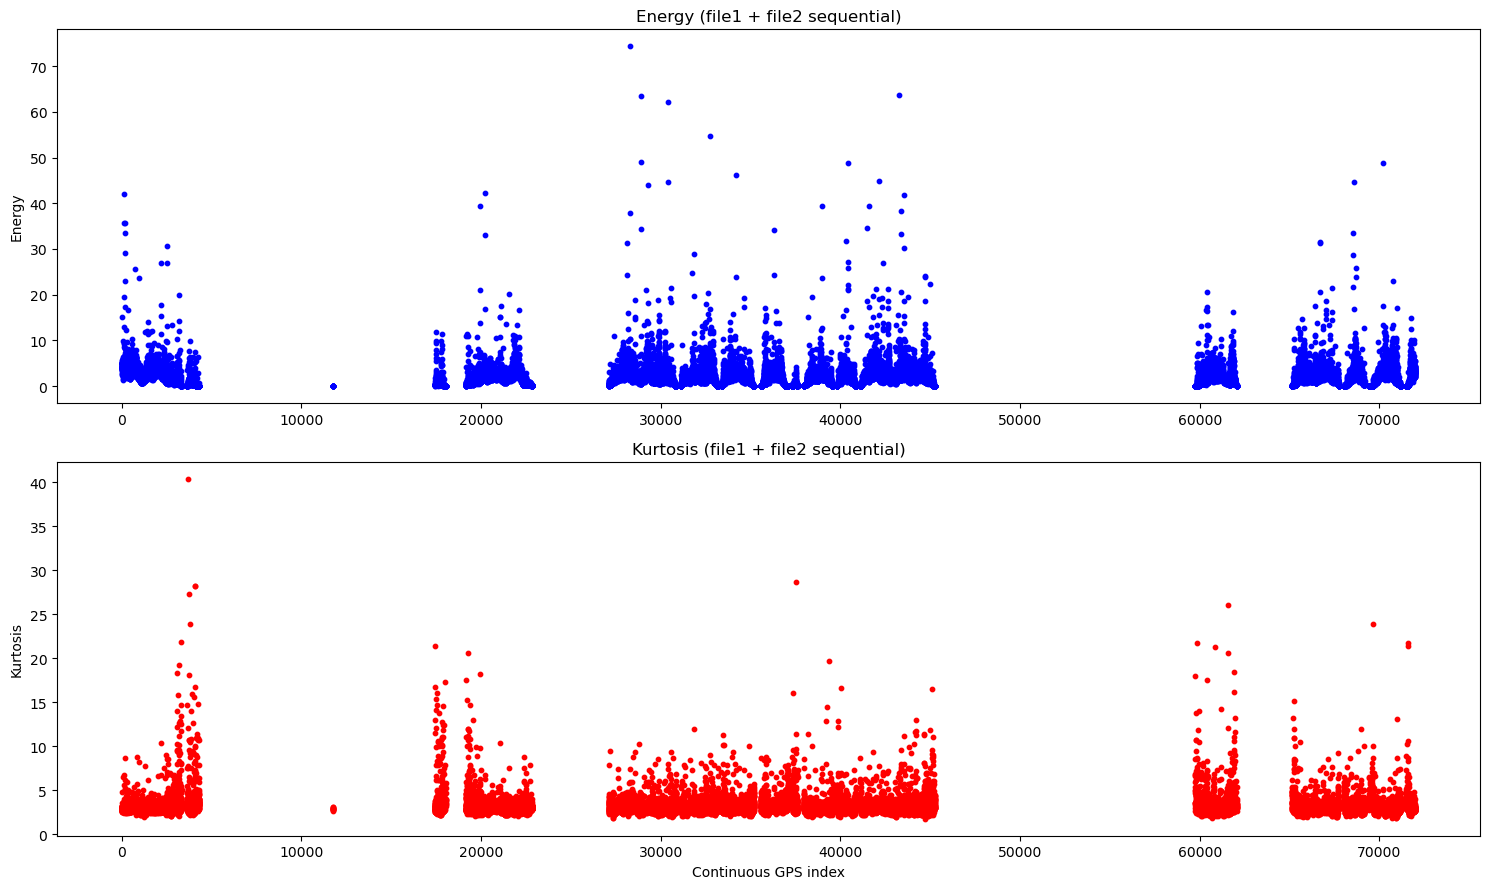

In [20]:
plt.figure(figsize=(15, 9))

# Split data
gps1 = gps[gps["file_label"] == "file1"].copy()
gps2 = gps[gps["file_label"] == "file2"].copy()

# Create continuous index
gps1["x"] = gps1["gps_index"]
offset = gps1["gps_index"].max() + 1
gps2["x"] = gps2["gps_index"] + offset

# Combine for plotting
gps_plot = pd.concat([gps1, gps2])

# --- Plot Energy ---
plt.subplot(2, 1, 1)
plt.scatter(gps_plot["x"], gps_plot["energy"], color='blue', s=10)
plt.title("Energy (file1 + file2 sequential)")
plt.ylabel("Energy")

# --- Plot Kurtosis ---
plt.subplot(2, 1, 2)
plt.scatter(gps_plot["x"], gps_plot["kurtosis"],color='red', s=10)
plt.title("Kurtosis (file1 + file2 sequential)")
plt.ylabel("Kurtosis")
plt.xlabel("Continuous GPS index")

plt.tight_layout()
plt.show()


There are many high Kurtosis and energy values that shall be extracted.

The criteria for selection is those GPS points that their energy are bigger than a threshold where it is 98% of whole energy data distribution.

In [21]:
eng_Percetile=98
threshold_eng=np.percentile(gps['energy'],eng_Percetile)
print(f"With percentile {eng_Percetile}% Threshold is:{threshold_eng}")
event_like_eng = gps['energy'] > threshold_eng
print("Event-like segments:", event_like_eng.sum())
detected_idx_eng = np.where(gps['energy'] > threshold_eng)[0]
#print(detected_idx_eng)

With percentile 98% Threshold is:7.166749141725216
Event-like segments: 656


The criteria for selection is those GPS points that their Kurtosis are bigger than a threshold where it is 98% of whole Kurtosis data distribution.

In [22]:
kur_Percetile=98
threshold_kur=np.percentile(gps['kurtosis'],kur_Percetile)
print(f"With percentile {kur_Percetile}% Threshold is:{threshold_kur}")
event_like_kur = gps['kurtosis'] > threshold_kur
print("Event-like segments:", event_like_kur.sum())
detected_idx_kur = np.where(gps['kurtosis'] > threshold_kur)[0]
#print(detected_idx_kur)

With percentile 98% Threshold is:5.628507673307205
Event-like segments: 656


It has interestingly been seen when the percentile is high, the number of selection GPS point with event becomes the same.

To understand how much the events are close together, the index of GPS points with events are investigated. 

1
979
49.81984732824427


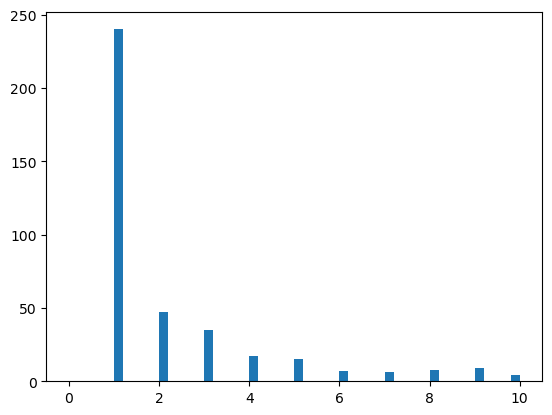

In [23]:
gaps_eng_diff = np.diff(detected_idx_eng)
#print(gaps_eng_diff)
print(gaps_eng_diff.min())
print(gaps_eng_diff.max())
print(gaps_eng_diff.mean())
plt.hist(gaps_eng_diff, bins=50, range=(0,10))
plt.show()

1
850
49.325190839694656


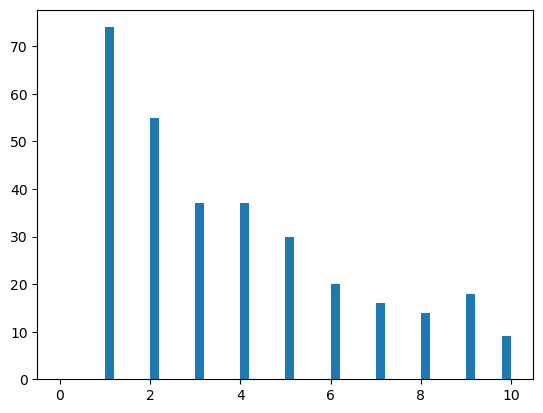

In [24]:
gaps_kur_diff = np.diff(detected_idx_kur)
#print(gaps_kur_diff)
print(gaps_kur_diff.min())
print(gaps_kur_diff.max())
print(gaps_kur_diff.mean())
plt.hist(gaps_kur_diff, bins=50, range=(0,10))
plt.show()

These graphs show that more than 35% of energy events are side by side (difference=1).

For Kurtosis the situation is better and Kurtosis events are distributed. 

Previously it has been calculated that the maximum speed is 44 m/s and the minimum distance between two marker is 4.9 meter that concludes the minimum time between two elements can reach to 100 ms and if GPS sample time is 50 ms, there is possibility that every two consecutive GPS point has valid event data.

In [25]:
MAX_GAP_eng = 2

clusters_eng = []
current_cluster_eng = [detected_idx_eng[0]]

for i in range(1, len(detected_idx_eng)):
    if detected_idx_eng[i] - detected_idx_eng[i-1] <= MAX_GAP_eng:  # same event
        current_cluster_eng.append(detected_idx_eng[i])
    else:
        clusters_eng.append(current_cluster_eng)
        current_cluster_eng = [detected_idx_eng[i]]

clusters_eng.append(current_cluster_eng)
print("Detected events:", len(clusters_eng))

Detected events: 369


In [26]:
MAX_GAP_kur = 2

clusters_kur = []
current_cluster_kur = [detected_idx_kur[0]]

for i in range(1, len(detected_idx_kur)):
    if detected_idx_kur[i] - detected_idx_kur[i-1] <= MAX_GAP_kur:  # same event
        current_cluster_kur.append(detected_idx_kur[i])
    else:
        clusters_kur.append(current_cluster_kur)
        current_cluster_kur = [detected_idx_kur[i]]

clusters_kur.append(current_cluster_kur)
print("Detected events:", len(clusters_kur))

Detected events: 527


In these part indexes of those selected GPS point with high energy or Kurtosis are calculated.

In [27]:
event_peaks_eng=[]
event_peaks_eng = [
    max(c, key=lambda idx: gps.iloc[idx]["energy"])
    for c in clusters_eng
]
print(len(event_peaks_eng))
event_coords_eng_deg = gps.loc[event_peaks_eng, ["Latitude", "Longitude"]].values
#print(event_coords_eng_deg)

369


In [28]:
event_peaks_kur=[]
event_peaks_kur = [
    max(c, key=lambda idx: gps.iloc[idx]["kurtosis"])
    for c in clusters_kur
]
print(len(event_peaks_kur))
event_coords_kur_deg = gps.loc[event_peaks_kur, ["Latitude", "Longitude"]].values
#print(event_coords_kur_deg)

527


The coordinate of those events are converted to radians for further distance calculation.

In [29]:
event_coords_eng = np.radians(event_coords_eng_deg)

In [30]:
event_coords_kur = np.radians(event_coords_kur_deg)

The distance between event and elements have been calculated by BallTree method.

MIN: 4.348320825752154
MAX: 1499.904349752371
MEAN: 262.5314415264552


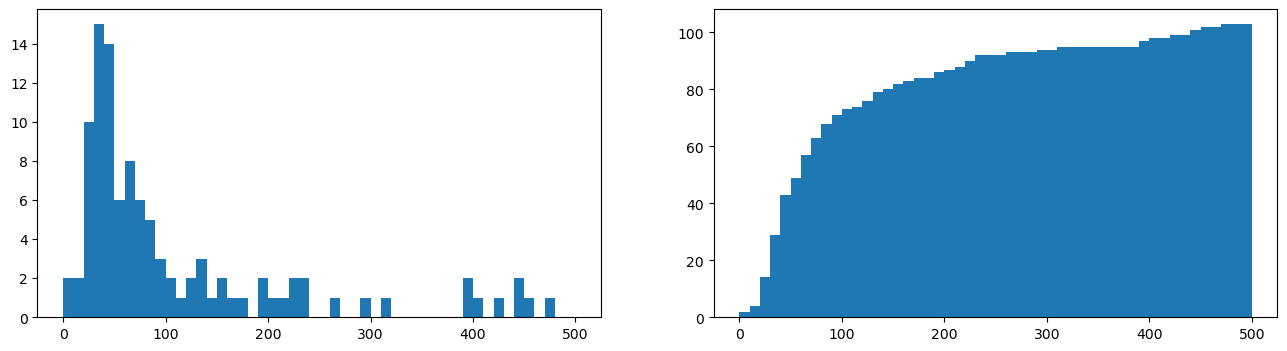

In [31]:
event_tree_eng = BallTree(event_coords_eng, metric='haversine')
dist4_eng, idx4_eng = event_tree_eng.query(marker_coords, k=1)

event_marker_eng_dist_m = dist4_eng.flatten() * earth_radius
idx_eng = idx4_eng.flatten()

#print(event_marker_eng_dist_m)
print("MIN:", event_marker_eng_dist_m.min())
print("MAX:", event_marker_eng_dist_m.max())
print("MEAN:", event_marker_eng_dist_m.mean())
plt.figure(figsize=(16, 4))
plt.subplot(1,2,1)
plt.hist(event_marker_eng_dist_m, range=(0,500),bins=50)
plt.subplot(1,2,2)
plt.hist(event_marker_eng_dist_m, bins=50, range=(0,500), cumulative=True)
plt.show()

This graphs show that distances between events and elements can reach 400 m if the outliers are excluded.

MIN: 4.143427671607015
MAX: 1416.3766597050787
MEAN: 228.09643133531586


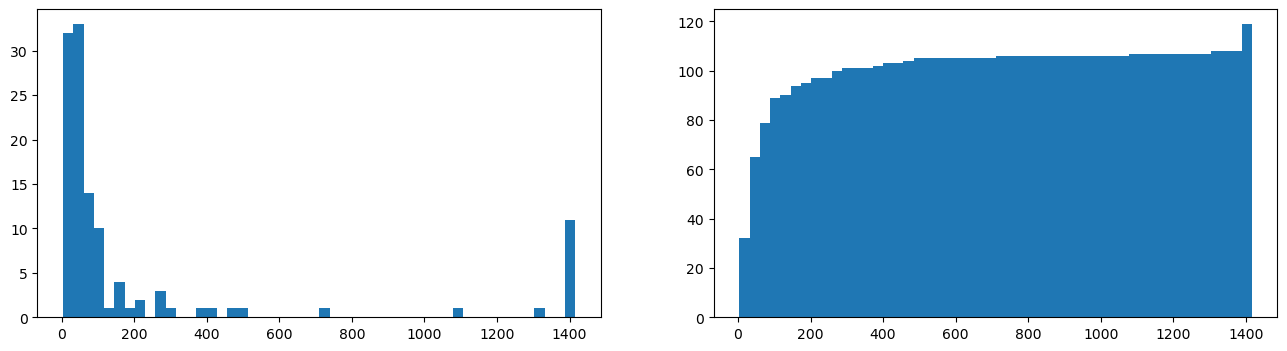

In [32]:
event_tree_kur = BallTree(event_coords_kur, metric='haversine')
dist4_kur, idx4_kur = event_tree_kur.query(marker_coords, k=1)

event_marker_kur_dist_m = dist4_kur.flatten() * earth_radius
idx_kur = idx4_kur.flatten()

#print(event_marker_kur_dist_m)
print("MIN:", event_marker_kur_dist_m.min())
print("MAX:", event_marker_kur_dist_m.max())
print("MEAN:", event_marker_kur_dist_m.mean())
plt.figure(figsize=(16, 4))
plt.subplot(1,2,1)
plt.hist(event_marker_kur_dist_m, bins=50)
plt.subplot(1,2,2)
plt.hist(event_marker_kur_dist_m, bins=50, cumulative=True)
plt.show()

This graph shows that status for Kurtosis is much better for distribution and it shows that Kurtosis has better resolution to distinguish events which are the same has been concluded in assignment 3. Threshold around 200m can include 95% of elements.

The number of selected elements which are in this maximum thresholds are selected in this step.

In [33]:
MAX_eng_DIST = 300  # meters

valid_eng = event_marker_eng_dist_m < MAX_eng_DIST

print("Matched markers:", np.sum(valid_eng))
print("Unmatched markers:", np.sum(~valid_eng))

Matched markers: 94
Unmatched markers: 25


In [34]:
MAX_kur_DIST = 200 # meters

valid_kur = event_marker_kur_dist_m < MAX_kur_DIST

print("Matched markers:", np.sum(valid_kur))
print("Unmatched markers:", np.sum(~valid_kur))

Matched markers: 95
Unmatched markers: 24


These two numbers show that around 95 events (from 119) have been located close to elements which are really good results.

In this step based on which elements is close to the event, it has been categorized. A window is selected in the case more neighborhoods shall be selected.

In [35]:
gps_eng=gps.copy()
gps_eng["Category"] = "Other"

WINDOW = 0

for i, (event_idx, d) in enumerate(zip(idx_eng, event_marker_eng_dist_m)):
    if d >= MAX_eng_DIST:
        continue

    gps_idx = event_peaks_eng[event_idx]
    category = markers.iloc[i]["Category"]

    start = max(0, gps_idx - WINDOW)
    end   = min(len(gps_eng) - 1, gps_idx + WINDOW)

    gps_eng.loc[start:end, "Category"] = category
    
gps_eng.info()
print(f"No of detected Bridge= {np.sum(gps_eng["Category"]=="Bridge")} vs {np.sum(marker_data["Category"]=="Bridge")} real bridge")
print(f"No of detected Rail Joint= {np.sum(gps_eng["Category"]=="RailJoint")} vs {np.sum(marker_data["Category"]=="RailJoint")} real rail joint")
print(f"No of detected Turnout= {np.sum(gps_eng["Category"]=="Turnout")} vs {np.sum(marker_data["Category"]=="Turnout")} real rail Turnout")
print(f"No of detected Other= {np.sum(gps_eng["Category"]=="Other")}")

<class 'pandas.DataFrame'>
RangeIndex: 32761 entries, 0 to 32760
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Latitude    32761 non-null  float64
 1   timestamp   32761 non-null  int64  
 2   Longitude   32761 non-null  float64
 3   PointIndex  32761 non-null  int64  
 4   speed       32761 non-null  float64
 5   speed_mps   32761 non-null  float64
 6   distance    32761 non-null  float64
 7   GPS_no      32761 non-null  int64  
 8   file_label  32761 non-null  str    
 9   gps_index   32761 non-null  int64  
 10  kurtosis    32761 non-null  float64
 11  energy      32761 non-null  float64
 12  Category    32761 non-null  str    
dtypes: float64(7), int64(4), str(2)
memory usage: 3.2 MB
No of detected Bridge= 11 vs 25 real bridge
No of detected Rail Joint= 14 vs 20 real rail joint
No of detected Turnout= 33 vs 74 real rail Turnout
No of detected Other= 32703


In [36]:
gps_kur=gps.copy()
gps_kur["Category"] = "Other"


for i, (event_idx, d) in enumerate(zip(idx_kur, event_marker_kur_dist_m)):
    if d > MAX_kur_DIST:
        continue   # ❗ ignore bad matches

    gps_kur_idx = event_peaks_kur[event_idx]
    category = markers.iloc[i]["Category"]

    gps_kur.loc[gps_kur_idx, "Category"] = category
gps_kur.info()
print(f"No of detected Bridge= {np.sum(gps_kur["Category"]=="Bridge")} vs {np.sum(marker_data["Category"]=="Bridge")} real bridge")
print(f"No of detected Rail Joint= {np.sum(gps_kur["Category"]=="RailJoint")} vs {np.sum(marker_data["Category"]=="RailJoint")} real rail joint")
print(f"No of detected Turnout= {np.sum(gps_kur["Category"]=="Turnout")} vs {np.sum(marker_data["Category"]=="Turnout")} real rail Turnout")
print(f"No of detected Other= {np.sum(gps_kur["Category"]=="Other")}")

<class 'pandas.DataFrame'>
RangeIndex: 32761 entries, 0 to 32760
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Latitude    32761 non-null  float64
 1   timestamp   32761 non-null  int64  
 2   Longitude   32761 non-null  float64
 3   PointIndex  32761 non-null  int64  
 4   speed       32761 non-null  float64
 5   speed_mps   32761 non-null  float64
 6   distance    32761 non-null  float64
 7   GPS_no      32761 non-null  int64  
 8   file_label  32761 non-null  str    
 9   gps_index   32761 non-null  int64  
 10  kurtosis    32761 non-null  float64
 11  energy      32761 non-null  float64
 12  Category    32761 non-null  str    
dtypes: float64(7), int64(4), str(2)
memory usage: 3.2 MB
No of detected Bridge= 13 vs 25 real bridge
No of detected Rail Joint= 12 vs 20 real rail joint
No of detected Turnout= 53 vs 74 real rail Turnout
No of detected Other= 32683


What have been observed in this part:
- almost all GPS point relevant to event close to the elements have been found
- some GPS points are far from markers (250 m) that haven't been found. These points can be added if more tracking data is loaded but due to limited resource on system, they have been omitted.

In this step vibrations are also labeled based on their relevant GPS point.

In [37]:
gps_eng_labels = gps_eng[["file_label", "PointIndex", "Category"]]

vib_eng_labeled = vib.merge(
    gps_eng_labels,
    left_on=["file_label", "gps_index"],
    right_on=["file_label", "PointIndex"],
    how="left"
)

print(f"All labeled GPS point numbers: {len(gps_eng_labels)}")
print(f"All labeled vibrations point numbers: {len(vib_eng_labeled)}")
gps_eng_labels.info()
vib_eng_labeled.info()


All labeled GPS point numbers: 32761
All labeled vibrations point numbers: 32744598
<class 'pandas.DataFrame'>
RangeIndex: 32761 entries, 0 to 32760
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   file_label  32761 non-null  str  
 1   PointIndex  32761 non-null  int64
 2   Category    32761 non-null  str  
dtypes: int64(1), str(2)
memory usage: 768.0 KB
<class 'pandas.DataFrame'>
RangeIndex: 32744598 entries, 0 to 32744597
Data columns (total 8 columns):
 #   Column        Dtype  
---  ------        -----  
 0   Vibration1    float64
 1   timestamp     int64  
 2   Vibration2    float64
 3   file_label    str    
 4   gps_index     int64  
 5   PointIndex_x  int64  
 6   PointIndex_y  int64  
 7   Category      str    
dtypes: float64(2), int64(4), str(2)
memory usage: 2.0 GB


In [38]:
gps_kur_labels = gps_kur[["file_label", "PointIndex", "Category"]]

vib_kur_labeled = vib.merge(
    gps_kur_labels,
    left_on=["file_label", "gps_index"],
    right_on=["file_label", "PointIndex"],
    how="left"
)

print(f"All labeled GPS point numbers: {len(gps_kur_labels)}")
print(f"All labeled vibrations point numbers: {len(vib_kur_labeled)}")
gps_kur_labels.info()
vib_kur_labeled.info()


All labeled GPS point numbers: 32761
All labeled vibrations point numbers: 32744598
<class 'pandas.DataFrame'>
RangeIndex: 32761 entries, 0 to 32760
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   file_label  32761 non-null  str  
 1   PointIndex  32761 non-null  int64
 2   Category    32761 non-null  str  
dtypes: int64(1), str(2)
memory usage: 768.0 KB
<class 'pandas.DataFrame'>
RangeIndex: 32744598 entries, 0 to 32744597
Data columns (total 8 columns):
 #   Column        Dtype  
---  ------        -----  
 0   Vibration1    float64
 1   timestamp     int64  
 2   Vibration2    float64
 3   file_label    str    
 4   gps_index     int64  
 5   PointIndex_x  int64  
 6   PointIndex_y  int64  
 7   Category      str    
dtypes: float64(2), int64(4), str(2)
memory usage: 2.0 GB


Finally, all unnecessary GPS and vibration data (labeled as "Other") are filtered out. Extra fields are removed from vibration data as well.

In [39]:
gps_eng_labeled = gps_eng[gps_eng["Category"] != "Other"]
vib_eng_labeled = vib_eng_labeled[vib_eng_labeled["Category"] != "Other"]

gps_eng_labeled = gps_eng_labeled[["Latitude", "timestamp", "Longitude", "PointIndex", "speed", "GPS_no", "file_label", "Category"]].copy()
vib_eng_labeled = vib_eng_labeled[["Vibration1", "timestamp", "Vibration2", "file_label", "gps_index", "Category"]].copy()

#print(gps_eng_labeled.isna().sum())
#print(vib_eng_labeled.isna().sum())
print(gps_eng_labeled.head(5))
#print(vib_eng_labeled.head(5))
print(f"All selected labeled GPS point numbers: {len(gps_eng_labeled)}")
print(f"All selected labeled vibrations point numbers: {len(vib_eng_labeled)}")


       Latitude  timestamp  Longitude  PointIndex      speed  GPS_no  \
113   60.910735        113  14.826202         113  146.44601       4   
154   60.912492        154  14.822122         154  138.56500       4   
206   60.914857        206  14.816780         206  134.36550       4   
1415  60.959418       1415  14.708029        1415  123.43200       4   
2812  61.006873       2812  14.577160        2812   62.99250       4   

     file_label Category  
113       file1  Turnout  
154       file1  Turnout  
206       file1  Turnout  
1415      file1   Bridge  
2812      file1  Turnout  
All selected labeled GPS point numbers: 58
All selected labeled vibrations point numbers: 57972


In [40]:
gps_kur_labeled = gps_kur[gps_kur["Category"] != "Other"]
vib_kur_labeled = vib_kur_labeled[vib_kur_labeled["Category"] != "Other"]

gps_kur_labeled = gps_kur_labeled[["Latitude", "timestamp", "Longitude", "PointIndex", "speed", "GPS_no", "file_label", "Category"]].copy()
vib_kur_labeled = vib_kur_labeled[["Vibration1", "timestamp", "Vibration2", "file_label", "gps_index", "Category"]].copy()

#print(gps_kur_labeled.isna().sum())
#print(vib_kur_labeled.isna().sum())
print(gps_kur_labeled.head(5))
#print(vib_kur_labeled.head(5))
print(f"All selected labeled GPS point numbers: {len(gps_kur_labeled)}")
print(f"All selected labeled vibrations point numbers: {len(vib_kur_labeled)}")

       Latitude  timestamp  Longitude  PointIndex       speed  GPS_no  \
206   60.914857        206  14.816780         206  134.365500       4   
2711  61.003998       2711  14.580101        2711   67.488000       4   
2795  61.006375       2795  14.577647        2795   62.918495       4   
2903  61.008476       2903  14.574357        2903   42.531498       4   
3714  61.007133       4019  14.546763        4019   34.724503       3   

     file_label Category  
206       file1  Turnout  
2711      file1  Turnout  
2795      file1  Turnout  
2903      file1   Bridge  
3714      file1  Turnout  
All selected labeled GPS point numbers: 78
All selected labeled vibrations point numbers: 77969


The selected GPS points and elements are illustrated in this figure. Black markers are GPS points and other colors are elements. In this figure, the excluded GPS points that are really far from loaded tracks are shown.

In [41]:
warnings.filterwarnings("ignore")

fig2 = go.Figure()

# Plot markers (Bridge, Turnout, etc.) ---
for category, style in marker_styles.items():
    category_data = marker_data[marker_data["Category"] == category]
    
    if len(category_data) > 0:
        fig2.add_trace(go.Scattermapbox(
            lat=category_data["Latitude"],
            lon=category_data["Longitude"],
            mode="markers",
            hovertext=marker_data.index,
            marker=dict(
                color=style["color"],
                size=style["size"]
            ),
            name=f"Marker: {category}"
        ))
    else:
        print(f"Skipping {category} - no marker data")

# Plot selected GPS points ---
gps_plot = gps_eng_labeled.copy()   # already filtered (no "Other")

fig2.add_trace(go.Scattermapbox(
    lat=gps_plot["Latitude"],
    lon=gps_plot["Longitude"],
    mode="markers",
    hovertext=gps_plot["Category"],
    marker=dict(
        color="black",
        size=6,
        opacity=0.5
    ),
    name="Selected GPS"
))

# Layout ---
fig2.update_layout(
    mapbox_style="open-street-map",
    title="Railway Map with Markers and Selected GPS Points (Approach 2)",
    legend_title_text="Legend",
    width=1200,
    height=800,
    margin={"r": 0, "t": 50, "l": 50, "b": 0},
    mapbox=dict(
        zoom=8.5,
        center=dict(
            lat=gps_plot["Latitude"].mean(),
            lon=gps_plot["Longitude"].mean()
        )
    )
)

if len(fig2.data) == 0:
    print("WARNING: No valid traces were added to the figure!")
else:
    figure_name="gps_elements_aproach2.png"
    fig2.write_image(
       figure_name,
        width=1200,       # pixels
        height=800,       # pixels
        scale=2           # scale=2 doubles resolution (good for reports)
    )
fig2.show(renderer="iframe")




In [42]:
warnings.filterwarnings("ignore")

fig2 = go.Figure()

# Plot markers (Bridge, Turnout, etc.) ---
for category, style in marker_styles.items():
    category_data = marker_data[marker_data["Category"] == category]
    
    if len(category_data) > 0:
        fig2.add_trace(go.Scattermapbox(
            lat=category_data["Latitude"],
            lon=category_data["Longitude"],
            mode="markers",
            hovertext=marker_data.index,
            marker=dict(
                color=style["color"],
                size=style["size"]
            ),
            name=f"Marker: {category}"
        ))
    else:
        print(f"Skipping {category} - no marker data")

# Plot selected GPS points ---
gps_plot = gps_kur_labeled.copy()   # already filtered (no "Other")

fig2.add_trace(go.Scattermapbox(
    lat=gps_plot["Latitude"],
    lon=gps_plot["Longitude"],
    mode="markers",
    hovertext=gps_plot["Category"],
    marker=dict(
        color="black",
        size=6,
        opacity=0.5
    ),
    name="Selected GPS"
))

# Layout ---
fig2.update_layout(
    mapbox_style="open-street-map",
    title="Railway Map with Markers and Selected GPS Points (Approach 2)",
    legend_title_text="Legend",
    width=1200,
    height=800,
    margin={"r": 0, "t": 50, "l": 50, "b": 0},
    mapbox=dict(
        zoom=8.5,
        center=dict(
            lat=gps_plot["Latitude"].mean(),
            lon=gps_plot["Longitude"].mean()
        )
    )
)

if len(fig2.data) == 0:
    print("WARNING: No valid traces were added to the figure!")
else:
    figure_name="gps_elements_aproach2.png"
    fig2.write_image(
       figure_name,
        width=1200,       # pixels
        height=800,       # pixels
        scale=2           # scale=2 doubles resolution (good for reports)
    )
fig2.show(renderer="iframe")




Instead of descriptive data, some binary data from elements has been generated in separated fields before saving this approach data.


In [43]:
# Initialize binary columns
gps_eng_labeled["Bridge"] = 0
gps_eng_labeled["Turnout"] = 0
gps_eng_labeled["RailJoint"] = 0

gps_eng_labeled.loc[gps_eng_labeled["Category"] == "Bridge", "Bridge"] = 1
gps_eng_labeled.loc[gps_eng_labeled["Category"] == "Turnout", "Turnout"] = 1
gps_eng_labeled.loc[gps_eng_labeled["Category"] == "RailJoint", "RailJoint"] = 1
gps_eng_labeled.info()
print(gps_eng_labeled.shape)
file_name_df_gps_labeled=f"gps_eng_labeled_data_approach2.csv"
gps_eng_labeled.to_csv(file_name_df_gps_labeled, index=False)
file_name_df_vibration_labeled=f"vibration_eng_labeled_data_approach2.csv"
vib_eng_labeled.to_csv(file_name_df_vibration_labeled, index=False)

<class 'pandas.DataFrame'>
Index: 58 entries, 113 to 32636
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Latitude    58 non-null     float64
 1   timestamp   58 non-null     int64  
 2   Longitude   58 non-null     float64
 3   PointIndex  58 non-null     int64  
 4   speed       58 non-null     float64
 5   GPS_no      58 non-null     int64  
 6   file_label  58 non-null     str    
 7   Category    58 non-null     str    
 8   Bridge      58 non-null     int64  
 9   Turnout     58 non-null     int64  
 10  RailJoint   58 non-null     int64  
dtypes: float64(3), int64(6), str(2)
memory usage: 5.4 KB
(58, 11)


In [44]:
# Initialize binary columns
gps_kur_labeled["Bridge"] = 0
gps_kur_labeled["Turnout"] = 0
gps_kur_labeled["RailJoint"] = 0

gps_kur_labeled.loc[gps_kur_labeled["Category"] == "Bridge", "Bridge"] = 1
gps_kur_labeled.loc[gps_kur_labeled["Category"] == "Turnout", "Turnout"] = 1
gps_kur_labeled.loc[gps_kur_labeled["Category"] == "RailJoint", "RailJoint"] = 1
print(gps_kur_labeled.shape)
file_name_df_gps_labeled=f"gps_kur_labeled_data_approach2.csv"
gps_kur_labeled.to_csv(file_name_df_gps_labeled, index=False)
file_name_df_vibration_labeled=f"vibration_kur_labeled_data_approach2.csv"
vib_kur_labeled.to_csv(file_name_df_vibration_labeled, index=False)

(78, 11)


## Discussion and Summary
In this report, the labeling of infrastructure elements has been carried out. These elements such as bridges, rail joints, and turnouts are defined by specific GPS coordinates. The available GPS and vibration datasets, collected from a train using onboard accelerometers, have been used to assign a categorical label (Bridge, Rail-joint, Turnout, or Other) to each vibration segment.

To ensure data quality, invalid data points were removed based on two criteria: low speed (below a defined threshold) and insufficient GPS satellite availability (below a threshold). This filtering step is particularly important to eliminate data collected when the train is stationary or when GPS accuracy is unreliable, such as outside the actual track path. The results indicate that approximately one-third of the data points were filtered out.

Visual inspection of both marker data and GPS trajectories shows that, despite using only a limited number of datasets (two files in this study due to system resource constraints), most infrastructure elements have corresponding nearby GPS points. Only a small number of elements (9 turnouts and 2 bridges) appear to lie outside the actual tracked path.

For spatial labeling, the data was filtered to retain only the segments corresponding to actual traversal over infrastructure elements (Bridge, Rail-joint, Turnout). Two different approaches were investigated:

### Approach 1: GPS-to-Element Matching

In this approach, each GPS point is matched to its nearest infrastructure element. Through visual inspection and parameter tuning (e.g., minimum distance and time window), it was observed that many elements can be detected correctly.

However, the number of detected segments is highly sensitive to the choice of distance threshold:

- A small threshold leads to missed detections.
- A large threshold results in excessive assignment of GPS points to elements.

Using a dynamic threshold (based on speed and time) improves resolution, especially when elements are located close to each other.

### Results of Approach 1

Despite these improvements:

- Some elements remain undetected even after parameter tuning.
- Too many GPS points may still be assigned to a single element.

While the latter issue could potentially be mitigated using vibration-based filtering, the inability to detect all elements reliably led to the exploration of a second approach. The results from this method are stored as Approach 1 data.

### Approach 2: Event-to-element Matching with Vibration Features

In this approach, For each GPS point when its corresponding segment has event, the nearest infrastructure marker/element within a specified maximum range is identified and marked.

Step to implement:
- Event in vibration data segment of each GPS point is detected. Kurtosis and energy of vibration have been used to detect availability of a event in each GPS point.
- Nearest marker when it is in a specific range has been selected.
A vibration-based feature (kurtosis) is evaluated across these candidates.
The GPS point with the most representative vibration signature is selected as the most likely match.

### Results of Approach 2

Both visual and numerical evaluations show that:
- Almost 85% of GPS points near infrastructure elements
- A small number of markers (with distances higher distance from available GPS points) remain unmatched. These could potentially be resolved by including more datasets, but were excluded here due to system limitations.
- For almost all marker, the kurtosis value is detecting elements better than energy (with higher resolution).

### Conclusion and Future Work

Approach 2 has been selected for further analysis due to its higher accuracy and better alignment with the physical characteristics of vibration signals.

However, Approach 1 remains of interest and could be further improved in future work, particularly by incorporating vibration-based filtering. Initial experiments indicate that such enhancements may improve detection performance, although they would likely increase computational cost.

A potential third approach is to combine more vibration features. In this method, significant vibration events are detected by weighted combined features as criteria for event detection then the corresponding GPS points are identified, and the nearest infrastructure element is assigned based on spatial proximity. 